Defaulting to user installation because normal site-packages is not writeable
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)

   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   ---------------------------------------- 2/2 [nbformat]



In [5]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [6]:
plant1_gen = pd.read_csv(
    r"C:\Users\aniru\Downloads\archive (4)\Plant_1_Generation_Data.csv"
)

plant1_weather = pd.read_csv(
    r"C:\Users\aniru\Downloads\archive (4)\Plant_1_Weather_Sensor_Data.csv"
)

plant2_gen = pd.read_csv(
    r"C:\Users\aniru\Downloads\archive (4)\Plant_2_Generation_Data.csv"
)

plant2_weather = pd.read_csv(
    r"C:\Users\aniru\Downloads\archive (4)\Plant_2_Weather_Sensor_Data.csv"
)

In [7]:
print("Plant 1 Generation :", plant1_gen.shape)
print("Plant 1 Weather    :", plant1_weather.shape)

print("Plant 2 Generation :", plant2_gen.shape)
print("Plant 2 Weather    :", plant2_weather.shape)

Plant 1 Generation : (68778, 7)
Plant 1 Weather    : (3182, 6)
Plant 2 Generation : (67698, 7)
Plant 2 Weather    : (3259, 6)


In [8]:
print(plant1_gen.columns)

print()

print(plant1_weather.columns)

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')


In [9]:
plant1_gen["DATE_TIME"] = pd.to_datetime(
    plant1_gen["DATE_TIME"]
)

plant1_weather["DATE_TIME"] = pd.to_datetime(
    plant1_weather["DATE_TIME"]
)

plant2_gen["DATE_TIME"] = pd.to_datetime(
    plant2_gen["DATE_TIME"]
)

plant2_weather["DATE_TIME"] = pd.to_datetime(
    plant2_weather["DATE_TIME"]
)

In [10]:
print(
    plant1_gen.isnull().sum()
)

print()

print(
    plant1_weather.isnull().sum()
)

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [11]:
print(plant1_weather.columns)

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')


In [12]:
plant1_weather_avg = (
    plant1_weather
    .groupby("DATE_TIME")
    .agg(
        {
            "AMBIENT_TEMPERATURE":"mean",
            "MODULE_TEMPERATURE":"mean",
            "IRRADIATION":"mean"
        }
    )
    .reset_index()
)

In [13]:
plant1 = pd.merge(
    plant1_gen,
    plant1_weather_avg,
    on="DATE_TIME",
    how="left"
)


In [14]:
plant2_weather_avg = (
    plant2_weather
    .groupby("DATE_TIME")
    .agg(
        {
            "AMBIENT_TEMPERATURE":"mean",
            "MODULE_TEMPERATURE":"mean",
            "IRRADIATION":"mean"
        }
    )
    .reset_index()
)

In [15]:
plant2 = pd.merge(
    plant2_gen,
    plant2_weather_avg,
    on="DATE_TIME",
    how="left"
)

In [16]:
print(
    plant1.shape
)

print(
    plant2.shape
)

plant1.head()

(68778, 10)
(67698, 10)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0


In [17]:
plant1.isnull().sum()

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
dtype: int64

In [18]:
plant1 = plant1.fillna(
    method="ffill"
)

plant2 = plant2.fillna(
    method="ffill"
)

In [19]:
plant1.isnull().sum()

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

In [20]:
plant1.to_csv(
    "plant1_clean.csv",
    index=False
)

plant2.to_csv(
    "plant2_clean.csv",
    index=False
)

In [21]:
plant1.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04,68778.000000,68778.000000,68778.000000
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06,25.558655,31.245892,0.232327
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,20.398505,18.140415,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06,22.724491,21.123944,0.000000
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06,24.670178,24.818984,0.031620
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06,27.960429,41.693659,0.454880
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,35.252486,65.545714,1.221652
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05,3.361248,12.308485,0.301953


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [23]:
plant1 = pd.read_csv(
    "plant1_clean.csv"
)

plant1["DATE_TIME"] = pd.to_datetime(
    plant1["DATE_TIME"]
)

print(plant1.shape)

plant1.head()

(68778, 10)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0


In [24]:
plant1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68778 non-null  datetime64[ns]
 1   PLANT_ID             68778 non-null  int64         
 2   SOURCE_KEY           68778 non-null  object        
 3   DC_POWER             68778 non-null  float64       
 4   AC_POWER             68778 non-null  float64       
 5   DAILY_YIELD          68778 non-null  float64       
 6   TOTAL_YIELD          68778 non-null  float64       
 7   AMBIENT_TEMPERATURE  68778 non-null  float64       
 8   MODULE_TEMPERATURE   68778 non-null  float64       
 9   IRRADIATION          68778 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 5.2+ MB


In [25]:
plant1.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04,68778.000000,68778.000000,68778.000000
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06,25.558655,31.245892,0.232327
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,20.398505,18.140415,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06,22.724491,21.123944,0.000000
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06,24.670178,24.818984,0.031620
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06,27.960429,41.693659,0.454880
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,35.252486,65.545714,1.221652
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05,3.361248,12.308485,0.301953


In [26]:
plant1.isnull().sum()

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

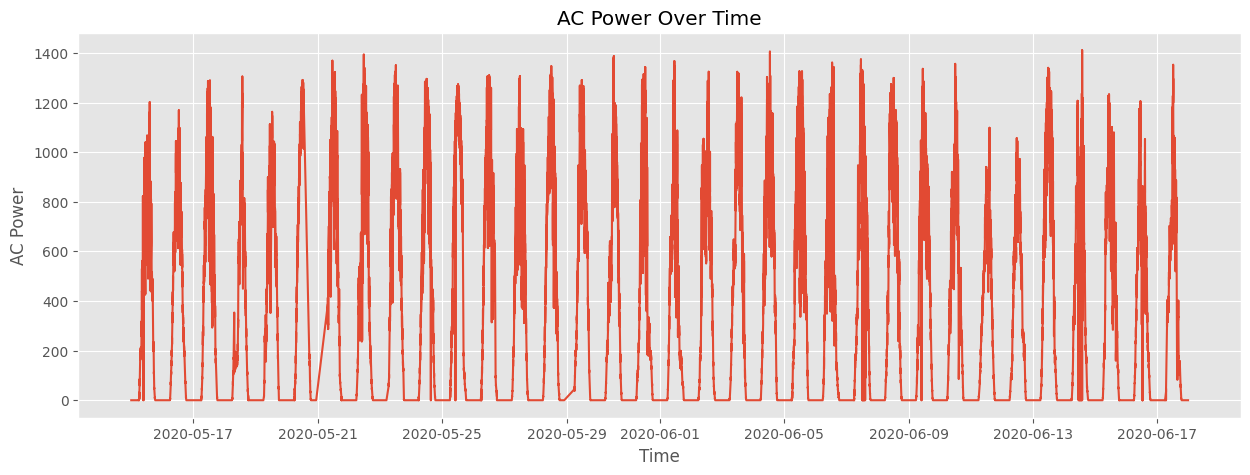

In [27]:
plt.figure(figsize=(15,5))

plt.plot(
    plant1["DATE_TIME"],
    plant1["AC_POWER"]
)

plt.title("AC Power Over Time")
plt.xlabel("Time")
plt.ylabel("AC Power")

plt.show()

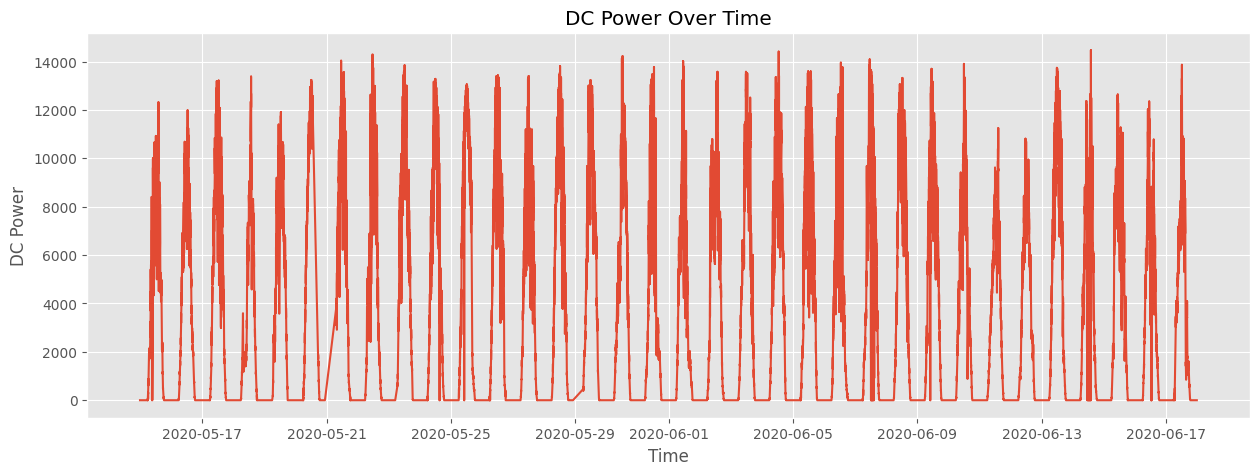

In [28]:
plt.figure(figsize=(15,5))

plt.plot(
    plant1["DATE_TIME"],
    plant1["DC_POWER"]
)

plt.title("DC Power Over Time")
plt.xlabel("Time")
plt.ylabel("DC Power")

plt.show()

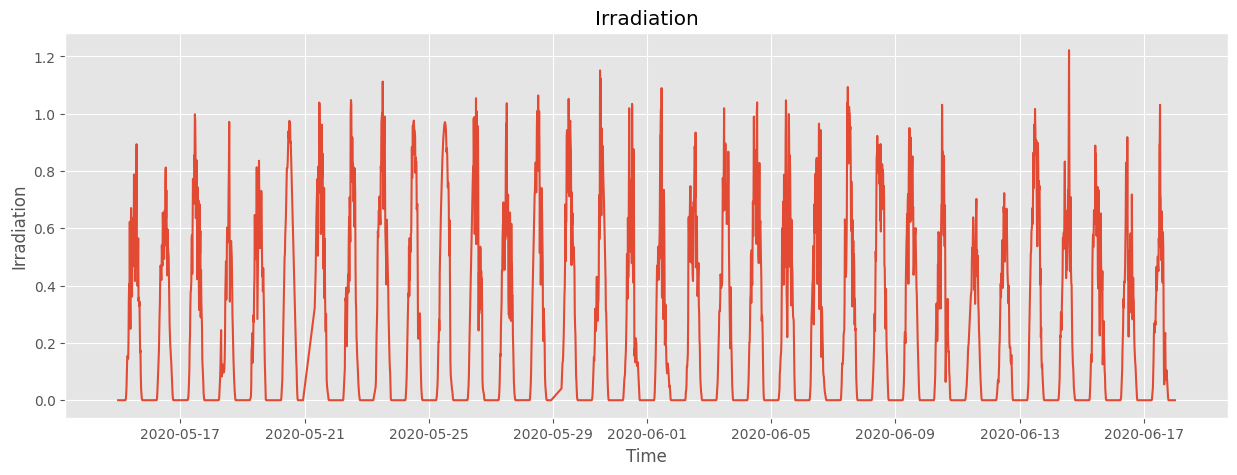

In [29]:
plt.figure(figsize=(15,5))

plt.plot(
    plant1["DATE_TIME"],
    plant1["IRRADIATION"]
)

plt.title("Irradiation")
plt.xlabel("Time")
plt.ylabel("Irradiation")

plt.show()

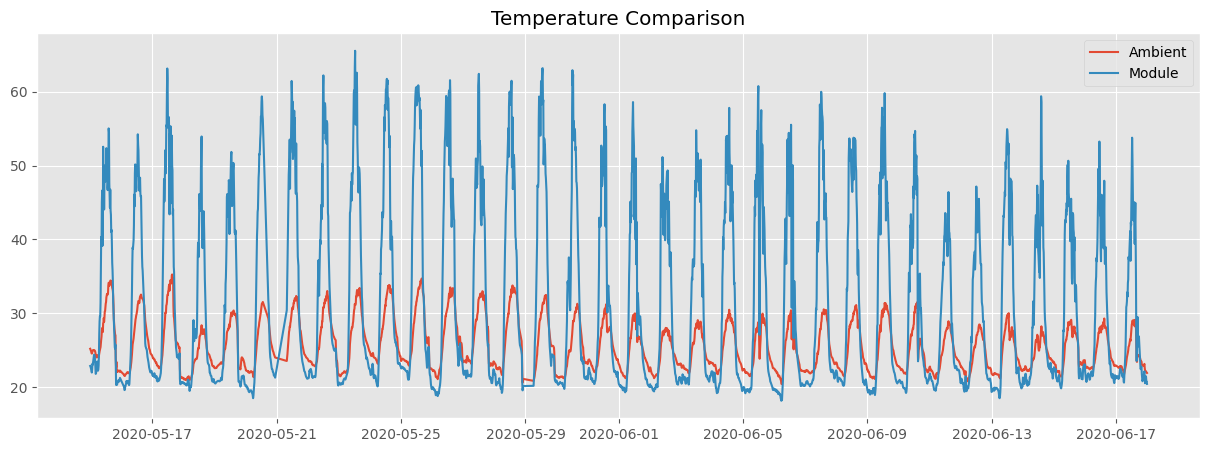

In [30]:
plt.figure(figsize=(15,5))

plt.plot(
    plant1["DATE_TIME"],
    plant1["AMBIENT_TEMPERATURE"],
    label="Ambient"
)

plt.plot(
    plant1["DATE_TIME"],
    plant1["MODULE_TEMPERATURE"],
    label="Module"
)

plt.legend()

plt.title("Temperature Comparison")

plt.show()

In [31]:
features = [
    "DC_POWER",
    "AC_POWER",
    "DAILY_YIELD",
    "TOTAL_YIELD",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]

In [32]:
corr = plant1[
    features
].corr(
    method="spearman"
)

corr

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DC_POWER,1.000000,1.000000,0.218726,-0.000903,0.744817,0.899653,0.987896
AC_POWER,1.000000,1.000000,0.218717,-0.000903,0.744792,0.899640,0.987893
DAILY_YIELD,0.218726,0.218717,1.000000,0.012178,0.553935,0.394382,0.217689
TOTAL_YIELD,-0.000903,-0.000903,0.012178,1.000000,-0.054670,-0.028312,-0.007266
AMBIENT_TEMPERATURE,0.744817,0.744792,0.553935,-0.054670,1.000000,0.910234,0.747078
MODULE_TEMPERATURE,0.899653,0.899640,0.394382,-0.028312,0.910234,1.000000,0.901510
IRRADIATION,0.987896,0.987893,0.217689,-0.007266,0.747078,0.901510,1.000000


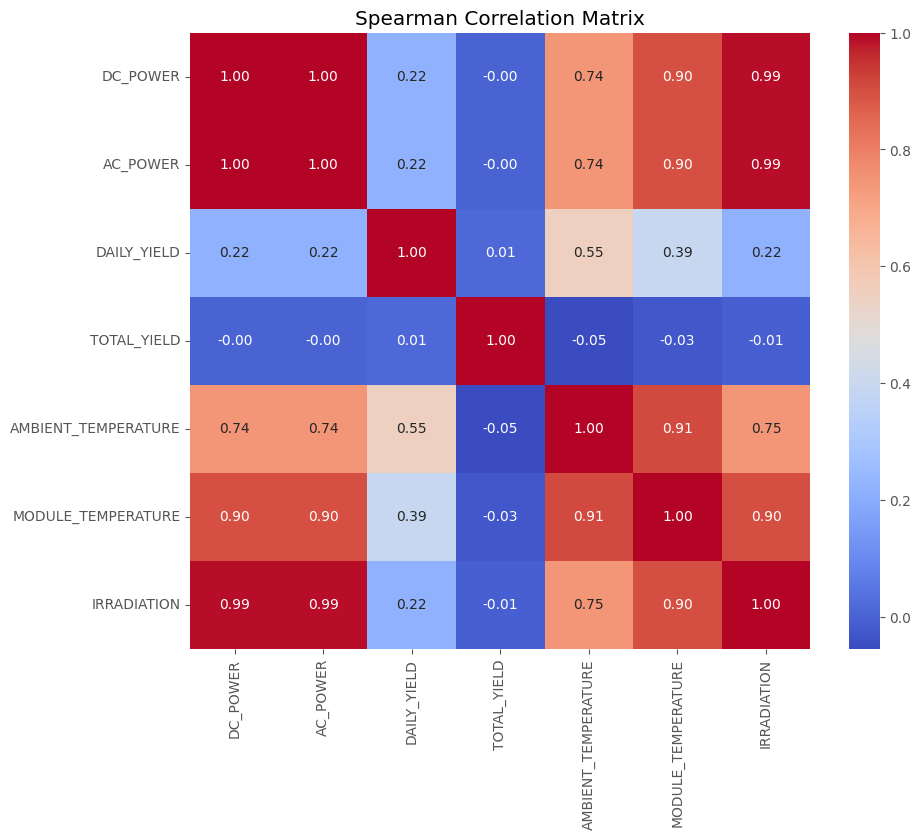

In [33]:
plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Spearman Correlation Matrix"
)

plt.show()

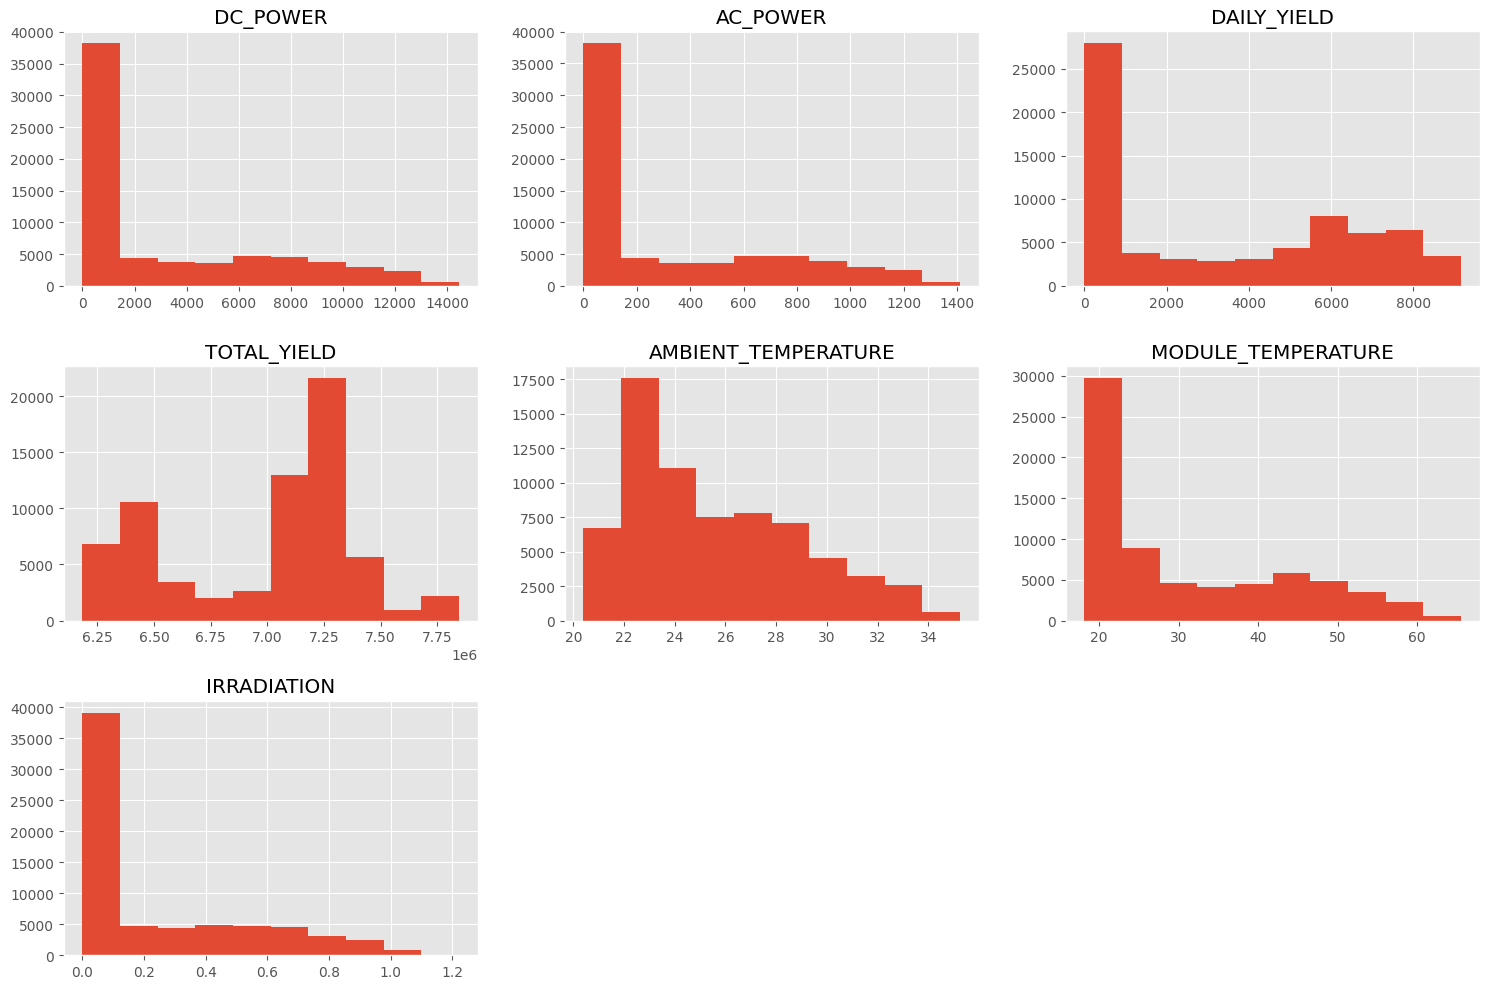

In [34]:
plant1[
    features
].hist(
    figsize=(15,10)
)

plt.tight_layout()

plt.show()

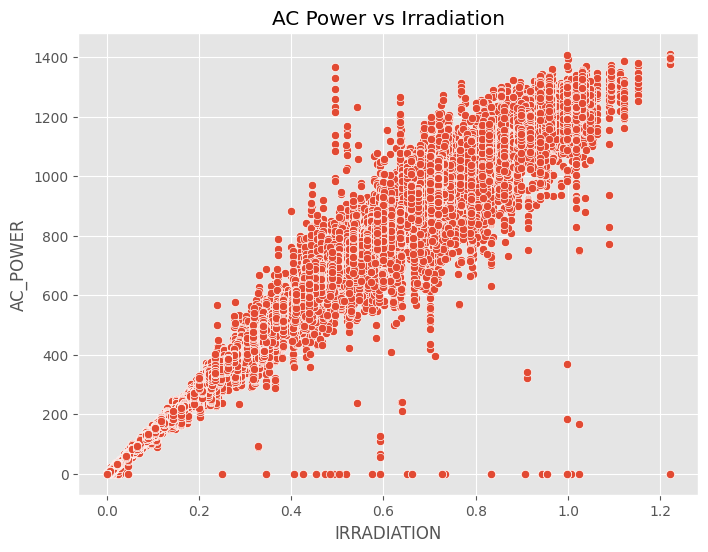

In [35]:
plt.figure(
    figsize=(8,6)
)

sns.scatterplot(
    data=plant1,
    x="IRRADIATION",
    y="AC_POWER"
)

plt.title(
    "AC Power vs Irradiation"
)

plt.show()

In [36]:
corr.to_csv(
    "correlation_matrix.csv"
)

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [38]:
plant1 = pd.read_csv(
    "plant1_clean.csv"
)

plant1["DATE_TIME"] = pd.to_datetime(
    plant1["DATE_TIME"]
)

plant1.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0


In [39]:
features = [
    "AC_POWER",
    "DC_POWER",
    "IRRADIATION"
]

In [40]:
model = IsolationForest(
    n_estimators=500,
    contamination=0.03,
    random_state=42
)

model.fit(
    plant1[features]
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",500
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [41]:
predictions = model.predict(
    plant1[features]
)

predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [42]:
plant1["anomaly"] = np.where(
    predictions == -1,
    1,
    0
)

In [43]:
print(
    plant1["anomaly"].value_counts()
)

anomaly
0    66714
1     2064
Name: count, dtype: int64


In [44]:
anomaly_percent = (
    plant1["anomaly"].mean()
    * 100
)

print(
    f"Anomaly Percentage: {anomaly_percent:.2f}%"
)

Anomaly Percentage: 3.00%


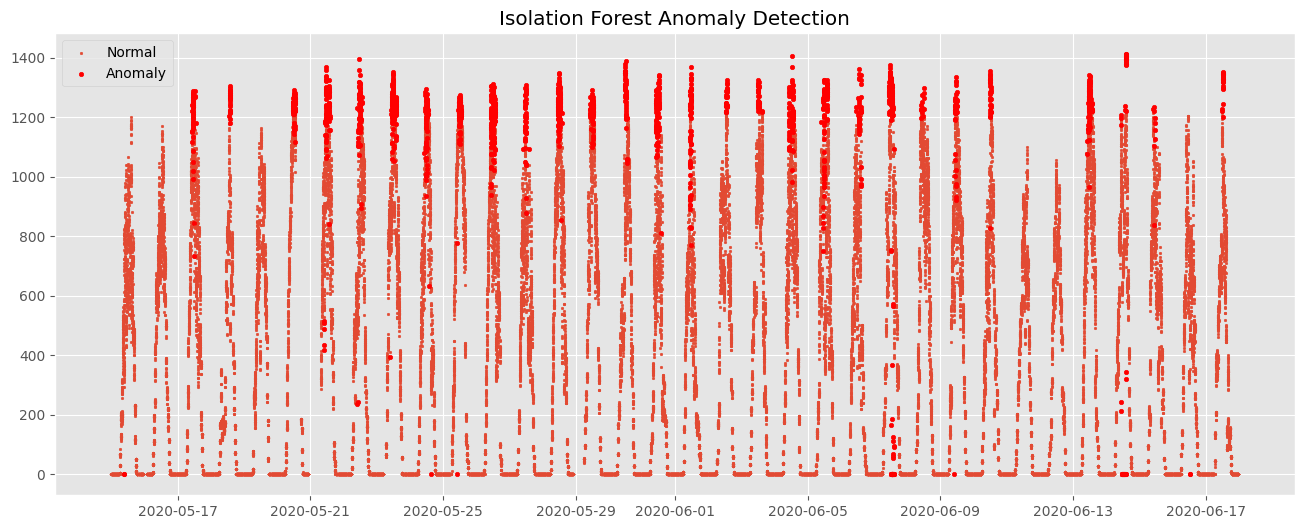

In [45]:
plt.figure(
    figsize=(16,6)
)

normal = plant1[
    plant1["anomaly"] == 0
]

anomaly = plant1[
    plant1["anomaly"] == 1
]

plt.scatter(
    normal["DATE_TIME"],
    normal["AC_POWER"],
    s=3,
    label="Normal"
)

plt.scatter(
    anomaly["DATE_TIME"],
    anomaly["AC_POWER"],
    color="red",
    s=10,
    label="Anomaly"
)

plt.legend()

plt.title(
    "Isolation Forest Anomaly Detection"
)

plt.show()

In [46]:
scores = model.decision_function(
    plant1[features]
)

plant1["anomaly_score"] = scores

plant1.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,anomaly,anomaly_score
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,0,0.269812
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,0,0.269812
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,0,0.269812
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0,0,0.269812
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0,0,0.269812


In [47]:
plant1.sort_values(
    "anomaly_score"
).head(20)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,anomaly,anomaly_score
61622,2020-06-14 14:00:00,4135001,sjndEbLyjtCKgGv,14357.42857,1399.842857,5215.857143,7240719.857,27.848916,59.386079,1.221652,1,-0.133483
61621,2020-06-14 14:00:00,4135001,rGa61gmuvPhdLxV,14285.71429,1392.842857,5221.285714,7335891.286,27.848916,59.386079,1.221652,1,-0.133483
61608,2020-06-14 14:00:00,4135001,3PZuoBAID5Wc2HD,14351.12500,1399.225000,5411.000000,7216130.000,27.848916,59.386079,1.221652,1,-0.133483
61615,2020-06-14 14:00:00,4135001,ZoEaEvLYb1n2sOq,14312.71429,1395.485714,5199.000000,7320962.000,27.848916,59.386079,1.221652,1,-0.133483
61627,2020-06-14 14:00:00,4135001,zVJPv84UY57bAof,14329.14286,1397.085714,5221.285714,7342181.286,27.848916,59.386079,1.221652,1,-0.133483
61624,2020-06-14 14:00:00,4135001,wCURE6d3bPkepu2,14471.12500,1410.950000,5178.250000,7007547.250,27.848916,59.386079,1.221652,1,-0.133483
61625,2020-06-14 14:00:00,4135001,z9Y9gH1T5YWrNuG,14370.50000,1401.125000,5121.625000,7230351.625,27.848916,59.386079,1.221652,1,-0.133483
61607,2020-06-14 14:00:00,4135001,1IF53ai7Xc0U56Y,14302.71429,1394.514286,5386.285714,6412267.286,27.848916,59.386079,1.221652,1,-0.133483
61611,2020-06-14 14:00:00,4135001,VHMLBKoKgIrUVDU,14299.85714,1394.214286,5374.714286,7434940.714,27.848916,59.386079,1.221652,1,-0.133483
61626,2020-06-14 14:00:00,4135001,zBIq5rxdHJRwDNY,14289.57143,1393.242857,5231.571429,6563053.571,27.848916,59.386079,1.221652,1,-0.133483


In [48]:
plant1.to_csv(
    "plant1_isolation_forest.csv",
    index=False
)

In [49]:
plant1["anomaly"].value_counts()

anomaly
0    66714
1     2064
Name: count, dtype: int64

In [50]:
plant1[
    plant1["anomaly"] == 1
].head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,anomaly,anomaly_score
815,2020-05-15 09:15:00,4135001,zVJPv84UY57bAof,0.00000,0.000000,711.000000,7116862.000,27.988362,46.617706,0.344884,1,-0.023620
837,2020-05-15 09:30:00,4135001,zVJPv84UY57bAof,0.00000,0.000000,711.000000,7116862.000,27.516728,39.136326,0.249248,1,-0.011100
4813,2020-05-17 10:30:00,4135001,1IF53ai7Xc0U56Y,11839.14286,1154.714286,2400.142857,6198994.143,30.158901,50.718400,0.685882,1,-0.015085
4814,2020-05-17 10:30:00,4135001,3PZuoBAID5Wc2HD,11445.71429,1117.142857,2397.571429,7003086.571,30.158901,50.718400,0.685882,1,-0.001235
4822,2020-05-17 10:30:00,4135001,adLQvlD726eNBSB,11778.71429,1149.600000,2429.571429,6286872.571,30.158901,50.718400,0.685882,1,-0.013945


In [51]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 2.3 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/12.1 MB 2.0 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/12.1 MB 2.2 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/12.1 MB 2.3 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.1 MB 2.4 MB/s eta 0:00:04
   ----------- ---------------------------- 3.4/12.1 MB 2.5 MB/s eta 0:00:04
   ------------ --------------------------- 3.9/12.1 MB 2.5 MB/s eta 0:00:04
   -------------- ------------------------- 4.5/12.1 MB 2.5 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.5 MB/s eta 0:00:03
   ----------

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\aniru\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [53]:
plant1 = pd.read_csv(
    "plant1_clean.csv"
)

plant1["DATE_TIME"] = pd.to_datetime(
    plant1["DATE_TIME"]
)

plant1.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0


In [54]:
ds
y

NameError: name 'ds' is not defined

In [ ]:
df_prophet = plant1[
    ["DATE_TIME", "AC_POWER"]
].copy()

df_prophet.columns = [
    "ds",
    "y"
]

df_prophet.head()

In [ ]:
df_prophet = (
    df_prophet
    .sort_values("ds")
    .reset_index(drop=True)
)

In [ ]:
split_index = int(
    len(df_prophet) * 0.8
)

train = df_prophet.iloc[:split_index]

test = df_prophet.iloc[split_index:]

In [ ]:
model = Prophet(
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.5,
    n_changepoints=200
)

In [ ]:
model.fit(train)

In [ ]:
future = test[
    ["ds"]
]

forecast = model.predict(
    future
)

forecast.head()

In [ ]:
y_true = test["y"].values

y_pred = forecast["yhat"].values

In [ ]:
mae = mean_absolute_error(
    y_true,
    y_pred
)

mse = mean_squared_error(
    y_true,
    y_pred
)

r2 = r2_score(
    y_true,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

In [ ]:
plt.figure(
    figsize=(16,6)
)

plt.plot(
    test["ds"],
    y_true,
    label="Actual"
)

plt.plot(
    test["ds"],
    y_pred,
    label="Forecast"
)

plt.legend()

plt.title(
    "Prophet Forecast"
)

plt.show()

In [ ]:
residuals = np.abs(
    y_true - y_pred
)

In [ ]:
threshold = np.percentile(
    residuals,
    95
)

print(
    threshold
)

In [ ]:
test = test.copy()

test["residual"] = residuals

test["anomaly"] = (
    residuals > threshold
).astype(int)

In [ ]:
test["anomaly"].value_counts()

In [ ]:
plt.figure(
    figsize=(16,6)
)

normal = test[
    test["anomaly"] == 0
]

anomaly = test[
    test["anomaly"] == 1
]

plt.scatter(
    normal["ds"],
    normal["y"],
    s=5,
    label="Normal"
)

plt.scatter(
    anomaly["ds"],
    anomaly["y"],
    color="red",
    s=20,
    label="Anomaly"
)

plt.legend()

plt.title(
    "Prophet Anomaly Detection"
)

plt.show()

In [ ]:
test.to_csv(
    "prophet_anomaly_results.csv",
    index=False
)

#AE-LSTM (Core Paper Model)

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    LSTM,
    RepeatVector,
    TimeDistributed,
    Dense
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [ ]:
plant1 = pd.read_csv(
    "plant1_clean.csv"
)

plant1["DATE_TIME"] = pd.to_datetime(
    plant1["DATE_TIME"]
)

plant1.head()

In [ ]:
signal = plant1[
    ["AC_POWER"]
].values

In [ ]:
scaler = MinMaxScaler()

scaled_signal = scaler.fit_transform(
    signal
)

In [ ]:
WINDOW = 24

In [ ]:
def create_sequences(
    data,
    seq_len
):

    sequences = []

    for i in range(
        len(data) - seq_len
    ):

        sequences.append(
            data[
                i:i+seq_len
            ]
        )

    return np.array(
        sequences
    )

In [ ]:
X = create_sequences(
    scaled_signal,
    WINDOW
)

print(X.shape)

In [ ]:
split_idx = int(
    len(X)*0.8
)

X_train = X[:split_idx]

X_test = X[split_idx:]

In [ ]:
inputs = Input(
    shape=(WINDOW,1)
)

x = LSTM(
    15,
    activation="relu",
    return_sequences=True
)(inputs)

x = LSTM(
    5,
    activation="relu",
    return_sequences=False
)(x)

x = RepeatVector(
    WINDOW
)(x)

x = LSTM(
    5,
    activation="relu",
    return_sequences=True
)(x)

x = LSTM(
    15,
    activation="relu",
    return_sequences=True
)(x)

outputs = TimeDistributed(
    Dense(1)
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    X_train,
    epochs=200,
    batch_size=20,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.title(
    "Training Loss"
)

plt.show()

In [ ]:
reconstructions = model.predict(
    X_test
)

In [ ]:
mse = np.mean(
    np.square(
        X_test - reconstructions
    ),
    axis=(1,2)
)

In [ ]:
threshold = np.percentile(
    mse,
    95
)

print(
    threshold
)

In [ ]:
anomalies = (
    mse > threshold
).astype(int)

pd.Series(
    anomalies
).value_counts()

In [ ]:
actual = X_test[:, -1, 0]

predicted = reconstructions[:, -1, 0]

In [ ]:
actual = scaler.inverse_transform(
    actual.reshape(-1,1)
)

predicted = scaler.inverse_transform(
    predicted.reshape(-1,1)
)

In [ ]:
mae = mean_absolute_error(
    actual,
    predicted
)

mse_metric = mean_squared_error(
    actual,
    predicted
)

r2 = r2_score(
    actual,
    predicted
)

print("MAE :", mae)
print("MSE :", mse_metric)
print("R2 :", r2)

In [ ]:
plt.figure(
    figsize=(16,6)
)

plt.plot(
    actual[:1000],
    label="Actual"
)

plt.plot(
    predicted[:1000],
    label="Reconstructed"
)

plt.legend()

plt.title(
    "AE-LSTM Reconstruction"
)

plt.show()

In [ ]:
results = pd.DataFrame({
    "actual":actual.flatten(),
    "predicted":predicted.flatten()
})

results.to_csv(
    "ae_lstm_results.csv",
    index=False
)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "Prophet",
        "AE-LSTM"
    ],
    "MAE": [
        np.nan,
        76.45,
        13.58
    ],
    "MSE": [
        np.nan,
        19798.23,
        1771.55
    ],
    "R2": [
        np.nan,
        0.8522,
        0.9868
    ]
})

comparison

In [ ]:
import matplotlib.pyplot as plt

comparison_plot = comparison.dropna()

plt.figure(figsize=(8,5))

plt.bar(
    comparison_plot["Model"],
    comparison_plot["R2"]
)

plt.ylabel("R²")
plt.title("Model Comparison")

plt.show()

In [ ]:
best_model = comparison_plot.loc[
    comparison_plot["R2"].idxmax()
]

best_model

In [ ]:
comparison.to_csv(
    "final_comparison.csv",
    index=False
)

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    RepeatVector,
    TimeDistributed,
    Bidirectional
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [ ]:
plant1 = pd.read_csv(
    "plant1_clean.csv"
)

plant1["DATE_TIME"] = pd.to_datetime(
    plant1["DATE_TIME"]
)

signal = plant1[
    ["AC_POWER"]
].values

In [ ]:
scaler = MinMaxScaler()

scaled_signal = scaler.fit_transform(
    signal
)

In [ ]:
WINDOW = 24

In [ ]:
def create_sequences(
    data,
    seq_len
):

    sequences = []

    for i in range(
        len(data)-seq_len
    ):
        sequences.append(
            data[
                i:i+seq_len
            ]
        )

    return np.array(
        sequences
    )

In [ ]:
X = create_sequences(
    scaled_signal,
    WINDOW
)

print(X.shape)

(68754, 24, 1)


In [ ]:
split_idx = int(
    len(X)*0.8
)

X_train = X[:split_idx]

X_test = X[split_idx:]

In [ ]:
inputs = Input(
    shape=(WINDOW,1)
)

x = Bidirectional(
    LSTM(
        15,
        activation="relu",
        return_sequences=True
    )
)(inputs)

x = Bidirectional(
    LSTM(
        5,
        activation="relu",
        return_sequences=False
    )
)(x)

x = RepeatVector(
    WINDOW
)(x)

x = Bidirectional(
    LSTM(
        5,
        activation="relu",
        return_sequences=True
    )
)(x)

x = Bidirectional(
    LSTM(
        15,
        activation="relu",
        return_sequences=True
    )
)(x)

outputs = TimeDistributed(
    Dense(1)
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 30)         │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 10)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 24, 10)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 24, 30)         │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 1)          │            31 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,271 (28.40 KB)

 Trainable params: 7,271 (28.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    X_train,
    epochs=200,
    batch_size=20,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 199s 74ms/step - loss: 0.0040 - val_loss: 8.9101e-04
Epoch 2/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 162s 66ms/step - loss: 0.0015 - val_loss: 6.9847e-04
Epoch 3/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 163s 66ms/step - loss: 0.0013 - val_loss: 6.4797e-04
Epoch 4/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 202s 66ms/step - loss: 0.0013 - val_loss: 6.8935e-04
Epoch 5/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 161s 65ms/step - loss: 0.0013 - val_loss: 8.2221e-04
Epoch 6/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 203s 65ms/step - loss: 0.0012 - val_loss: 5.5982e-04
Epoch 7/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 160s 65ms/step - loss: 0.0012 - val_loss: 5.5217e-04
Epoch 8/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 161s 65ms/step - loss: 0.0011 - val_loss: 5.8069e-04
Epoch 9/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 202s 65ms/step - loss: 0.0011 - val_loss: 5.4712e-04
Epoch 10/200
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 160s 64ms/step - loss: 0.0011 - val_loss: 5.4670e-04
Epoch 11/200
2476/2476 ━━━━━━━━━━━━━━━━

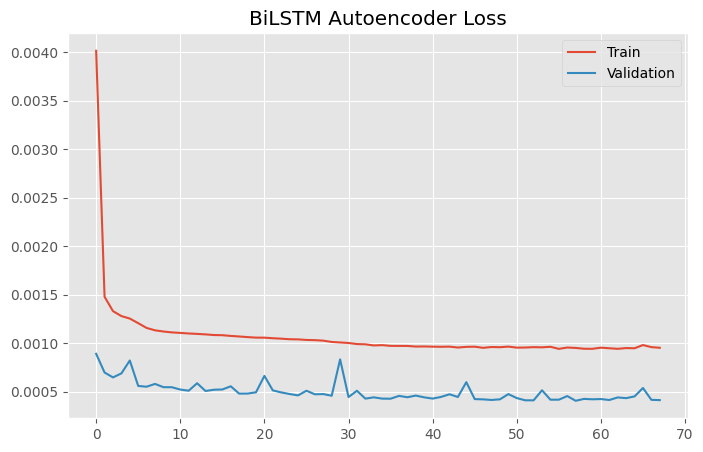

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.title(
    "BiLSTM Autoencoder Loss"
)

plt.show()

In [ ]:
reconstructions = model.predict(
    X_test
)

430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step


In [ ]:
reconstruction_error = np.mean(
    np.square(
        X_test - reconstructions
    ),
    axis=(1,2)
)

In [ ]:
threshold = np.percentile(
    reconstruction_error,
    95
)

print(threshold)

0.0023253709423456973


In [ ]:
anomalies = (
    reconstruction_error > threshold
).astype(int)

pd.Series(
    anomalies
).value_counts()

,count
0,13063
1,688


In [ ]:
actual = X_test[:, -1, 0]

predicted = reconstructions[:, -1, 0]

In [ ]:
actual = scaler.inverse_transform(
    actual.reshape(-1,1)
)

predicted = scaler.inverse_transform(
    predicted.reshape(-1,1)
)

In [ ]:
mae = mean_absolute_error(
    actual,
    predicted
)

mse = mean_squared_error(
    actual,
    predicted
)

r2 = r2_score(
    actual,
    predicted
)

print("MAE :", mae)
print("MSE :", mse)
print("R2 :", r2)

MAE : 14.188528676230947
MSE : 1779.780169105267
R2 : 0.9867124456008798


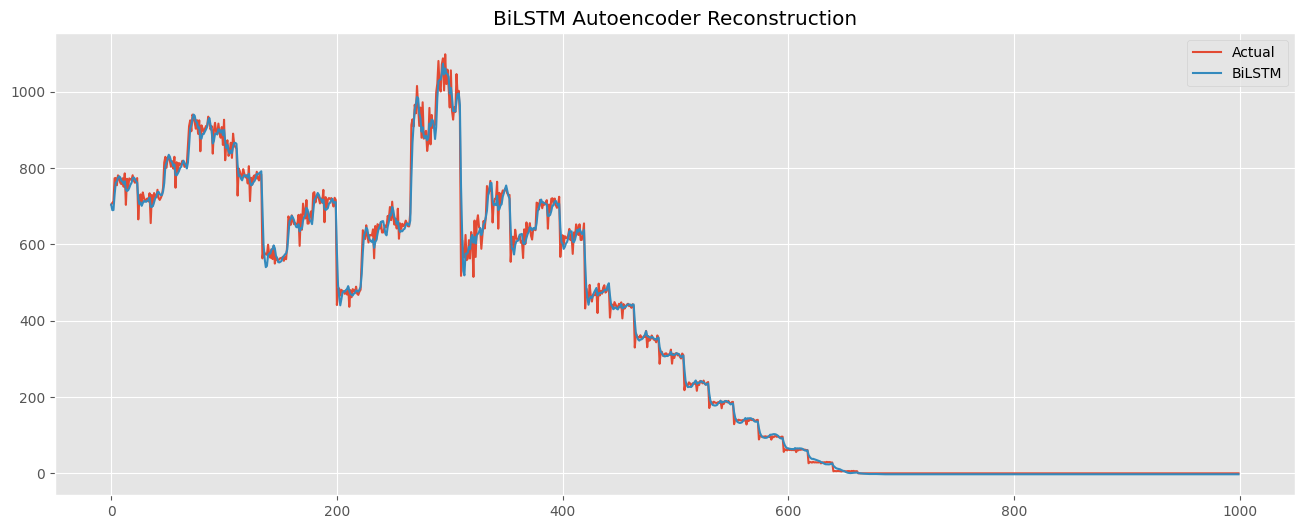

In [ ]:
plt.figure(
    figsize=(16,6)
)

plt.plot(
    actual[:1000],
    label="Actual"
)

plt.plot(
    predicted[:1000],
    label="BiLSTM"
)

plt.legend()

plt.title(
    "BiLSTM Autoencoder Reconstruction"
)

plt.show()